In [1]:
import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")

import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from diffPLOG2TROE.rate_constants import FallOff, Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter

## H+NO

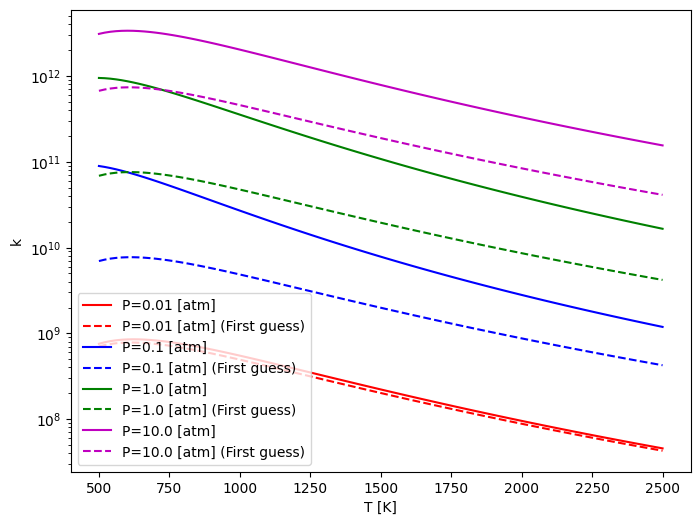

In [2]:
plog = {
    "name": "H+NO(+M)=H2NO(+M)",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.01  ,.5670E+24,  -4.590, 5690.0],
            [0.10  ,.5690E+26,  -4.800, 4233.0],
            [1.00  ,.2680E+28,  -4.940, 4849.0],
            [10.0  ,.2550E+28,  -4.630, 5539.0],
            [100.0 ,.4840E+26,  -3.870, 5867.0],
        ]
    }
}
constant = Plog(plog)

# These values are the one computed directly by the refitter class as its shown in the next cells
troe = FallOff(
    name="H+NO(+M)=H2NO(+M)",
    hpl_params=jnp.array([2550E+28,  -4.630, 5539.0]),
    lpl_params=jnp.array([4.653e+27, -3.590, 5.690e+03]),
    falloff_params=jnp.array([0.500, 1.050e+03, 3.000e+02, 2.250e+03, 0.]),
    falloff_type=1
)

T_range = jnp.linspace(500, 2500, 100)
P_range = jnp.logspace(jnp.log10(0.01), jnp.log10(10), 100)
P_levels = jnp.array([0.01, 0.1, 1, 10])

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (First guess)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()

Known that the high pressure limit for this reaction has been measured when we are going to refit its values into a TROE we are going to fix these values consistently

In [11]:
refitter = PlogRefitter(
    plog_dict=plog,
    T_range=(500, 2500),
    P_range=(0.01, 10),
    fitting_mode="duplicate",
    primary_falloff_type="troe",
    log_name="OH_NO__OHNO.log"
)
results = refitter.optimize(
    max_iterations=1000,
    uncertainty_factor=0.5,
    uncertainty_type="symmetric",
    tol=1e-10
)

Plog to Duplicate Reactions (troe + lindemann) refitter
 Temperature range [K]: (500, 2500)
 Pressure range [atm]: (0.01, 10)
 Loss function: rmsle

Parameters configuration:

Primary reaction (troe):
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: optimizing from default initial value
  n_high: optimizing from default initial value
  E_high: optimizing from default initial value
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value

Secondary reaction (lindemann):
  secondary_A_low: optimizing from default initial value
  secondary_n_low: optimizing from default initial value
  secondary_E_low: optimizing from default initial value
  secondary_A_high: optimizing from default initial value
  secondary_n_high: optimizing from default initial value
  secondary_E_high:

[ 2.05835523e+01 -9.01204158e+00  2.86330148e+03  8.10790277e+01
 -1.38680231e+01  2.78730871e+03  5.45561976e-01  1.05002476e+03
  3.00061148e+02  2.24999401e+03  6.59962566e+01 -3.78160000e+00
  2.46879000e+03  1.13226581e+02 -6.47429038e+00  2.78728041e+03]


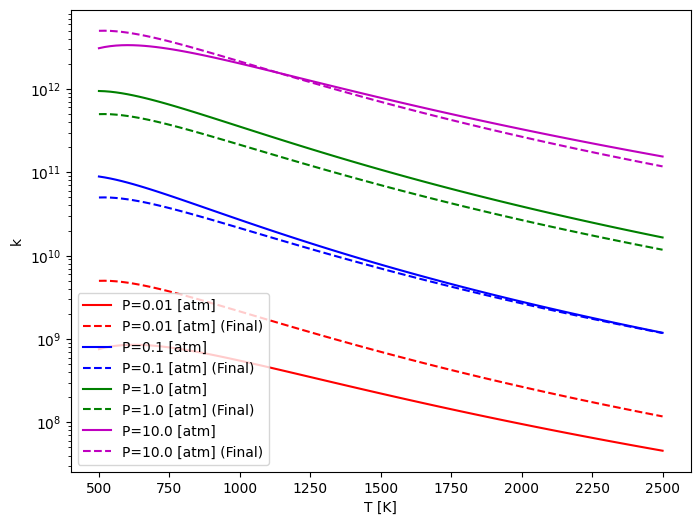

OH+NO(+M)=OHNO(+M)		1.62995e+35 -13.86802 5.53838e+03
 LOW / 		8.69607e+08 -9.01204 5.68938e+03 /
 TROE / 5.45562e-01 1.05002e+03 3.00061e+02 2.24999e+03 /
OH+NO(+M)=OHNO(+M)		1.49169e+49 -6.47429 5.53833e+03
 LOW / 		4.58997e+28 -3.78160 4.90549e+03 /



In [12]:
params = results["optimized_params"]
print(params)
troe1 = FallOff(
    name="OH+NO(+M)=OHNO(+M)",
    lpl_params=jnp.array([jnp.exp(params[0]), params[1], params[2]*1.987]),
    hpl_params=jnp.array([jnp.exp(params[3]), params[4], params[5]*1.987]),
    falloff_params=jnp.array([params[6], params[7], params[8], params[9], 0]),
    falloff_type=1
)
lind1 = FallOff(
    name="OH+NO(+M)=OHNO(+M)",
    lpl_params=jnp.array([jnp.exp(params[10]), params[11], params[12]*1.987]),
    hpl_params=jnp.array([jnp.exp(params[13]), params[14], params[15]*1.987]),
    falloff_params=jnp.array([0, 0, 0, 0, 0]),
    falloff_type=0
)

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe = troe1.kinetic_constant(T_range, P_levels)
k_lind = lind1.kinetic_constant(T_range, P_levels)

k_fin = k_troe + k_lind

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_fin)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (Final)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()
print(troe1)
print(lind1)

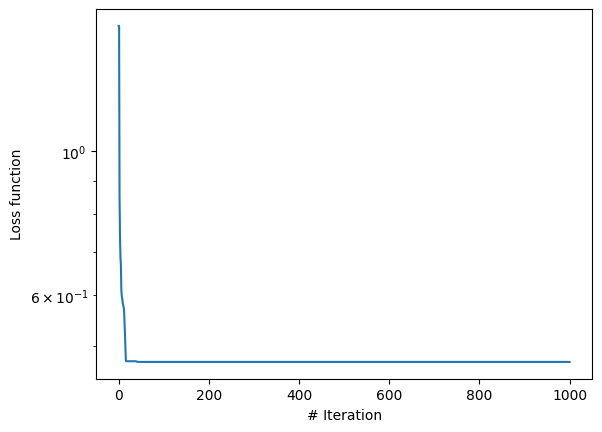

In [13]:
plt.semilogy(results["loss_history"])
plt.xlabel("# Iteration")
plt.ylabel("Loss function")
plt.show()

Minimum error: 1.876555832672112e-38
Maximum error: 4.188807386340967e-34
Average error: 1.0


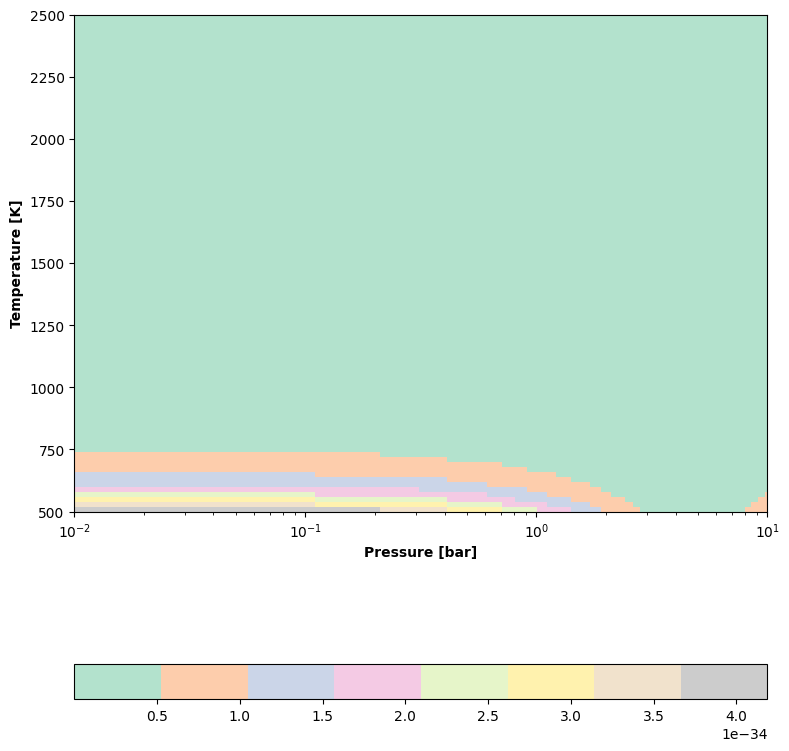

In [14]:
T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

k_plog = constant.kinetic_constant(T_range, P_range)
k_troe = troe.kinetic_constant(T_range, P_range)

ratio = k_troe.T / k_plog.T
rel_ratio = jnp.mean(jnp.sqrt((1 - k_troe.T / k_plog.T) ** 2))

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel2"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {rel_ratio}")

plt.tight_layout()
plt.show()